# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/titlyzaman25/flyrank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
import random
import numpy as np
import pandas as pd

from huggingface_hub import hf_hub_download

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Seed:", SEED)

Seed: 42


In [2]:
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")

march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset", token=HF_TOKEN
)
march = pd.read_parquet(march_file)

content_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset", token=HF_TOKEN
)
content = pd.read_parquet(content_file)

april_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-04/data_0.parquet",
    repo_type="dataset", token=HF_TOKEN
)
april = pd.read_parquet(april_file)

print("March rows:", len(march), "| April rows:", len(april), "| Content rows:", len(content))

March rows: 9841378 | April rows: 10424730 | Content rows: 519606


In [3]:
march_content = (
    march.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        gsc_impressions=("gsc_impressions", "sum"),
        gsc_clicks=("gsc_clicks", "sum"),
        gsc_avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        ga4_total_engagement_sec=("ga4_total_engagement_sec", "sum")
    )
)

march_content["ctr"] = np.where(
    march_content["gsc_impressions"] > 0,
    march_content["gsc_clicks"] / march_content["gsc_impressions"],
    np.nan
)

metadata_cols = [
    "client_hash_id", "content_hash_id", "content_created_date",
    "content_updated_date", "last_optimized_date", "content_type",
    "search_volume", "competition", "main_intent", "word_count",
    "char_count", "is_published", "is_deleted"
]
content_meta = content[metadata_cols].copy()

baseline = march_content.merge(content_meta, on=["client_hash_id", "content_hash_id"], how="left")

CUTOFF_DATE = pd.Timestamp("2026-03-31")
baseline["content_updated_date"] = pd.to_datetime(baseline["content_updated_date"], errors="coerce")
baseline["days_since_update"] = (CUTOFF_DATE - baseline["content_updated_date"]).dt.days
baseline.loc[baseline["days_since_update"] < 0, "days_since_update"] = np.nan

print("Baseline rows:", len(baseline))

Baseline rows: 331437


In [4]:
april_content = (
    april.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(april_impressions=("gsc_impressions", "sum"), april_clicks=("gsc_clicks", "sum"))
)
april_content["future_click_label"] = (april_content["april_clicks"] > 0).astype(int)

model_df = baseline.merge(
    april_content[["client_hash_id", "content_hash_id", "future_click_label"]],
    on=["client_hash_id", "content_hash_id"], how="inner"
)

FEATURES = [
    "gsc_impressions", "gsc_clicks", "gsc_avg_position",
    "ga4_sessions", "ga4_total_engagement_sec", "ctr", "days_since_update"
]

print("model_df rows:", len(model_df))
print("Label rate:", model_df["future_click_label"].mean())
print("Missing values:\n", model_df[FEATURES].isna().sum())

model_df rows: 331436
Label rate: 0.18736045571392365
Missing values:
 gsc_impressions                  0
gsc_clicks                       0
gsc_avg_position            154699
ga4_sessions                     0
ga4_total_engagement_sec         0
ctr                         154699
days_since_update           293357
dtype: int64


In [5]:
X = model_df[FEATURES].copy()
y = model_df["future_click_label"].copy()
groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])
model.fit(X_train, y_train)

model_prob = model.predict_proba(X_test)[:, 1]
model_pred = (model_prob >= 0.5).astype(int)

model_auc = roc_auc_score(y_test, model_prob)
model_precision = precision_score(y_test, model_pred, zero_division=0)
model_recall = recall_score(y_test, model_pred, zero_division=0)
model_f1 = f1_score(y_test, model_pred, zero_division=0)

print("Grouped-split metrics")
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1       :", round(model_f1, 4))
print("ROC-AUC  :", round(model_auc, 4))

Grouped-split metrics
Precision: 0.9311
Recall   : 0.5097
F1       : 0.6588
ROC-AUC  : 0.92


In [6]:
# A single grouped train/test split only validates the test slice.
# The playbook needs a trustworthy score for EVERY row, so use GroupKFold
# to get an out-of-sample prediction for each row without any row being
# scored by a model that saw it (or its client) during training.

from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
oof_prob = np.full(len(model_df), np.nan)

for fold_train_idx, fold_test_idx in gkf.split(X, y, groups=groups):
    fold_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
    ])
    fold_model.fit(X.iloc[fold_train_idx], y.iloc[fold_train_idx])
    oof_prob[fold_test_idx] = fold_model.predict_proba(X.iloc[fold_test_idx])[:, 1]

model_df["oof_probability"] = oof_prob

print("Rows scored out-of-fold:", np.isfinite(oof_prob).sum(), "/", len(model_df))
print("Mean OOF probability:", round(np.nanmean(oof_prob), 4))
print("Actual label rate    :", round(y.mean(), 4))

Rows scored out-of-fold: 331436 / 331436
Mean OOF probability: 0.1891
Actual label rate    : 0.1874


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks every scored content item into one of six reason codes, ordered by
out-of-fold predicted potential within each code:

- **REFRESH_PRIORITY** — stale content (>180 days since update) that the model still
  scores medium/high potential. First priority: the refresh effort is likely to land on
  content that still has demand.
- **STRIKING_DISTANCE_PUSH** — ranking positions 11-20 with high predicted potential.
  Close to page 1; a relevance/linking pass may be enough to move it.
- **MAINTAIN_MONITOR** — already on page 1 with high predicted potential. No action
  needed, just don't let it slip.
- **REVIEW_QUEUE** — doesn't cleanly match a defined archetype. Routed to a human, not
  auto-assigned an action.
- **NO_ACTION_LOW_VALUE** — deep position, low predicted potential. Not prioritized this
  cycle — this is a "not now," not a verdict on quality.
- **MONITOR_ONLY** — low predicted potential elsewhere in the funnel. Tracked, not acted on.

In this dataset, `[X]` items landed in REFRESH_PRIORITY, `[Y]` in STRIKING_DISTANCE_PUSH,
and `[Z]%` of the total queue was flagged for mandatory human review before any suggestion
reaches an editor.

**Decay/refresh insight (observed, this portfolio):** stale content shows a lower mean
out-of-fold predicted potential (`[A]`) than fresh content (`[B]`) — see the freshness-tier
table above. This is a directional pattern in one portfolio over one 2-month window, not
evidence that refreshing any specific page will produce a specific lift.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
queue = model_df.copy()

queue["position_tier"] = np.select(
    [queue["gsc_avg_position"].between(1, 10),
     queue["gsc_avg_position"].between(11, 20),
     queue["gsc_avg_position"] > 20],
    ["top_page1", "striking_distance", "deep"],
    default="no_position_data"
)

queue["freshness_tier"] = np.select(
    [queue["days_since_update"] <= 90,
     queue["days_since_update"].between(91, 180),
     queue["days_since_update"] > 180],
    ["fresh", "moderate", "stale"],
    default="unknown"
)

prob_terciles = queue["oof_probability"].quantile([1/3, 2/3])
queue["probability_tier"] = np.select(
    [queue["oof_probability"] >= prob_terciles.iloc[1],
     queue["oof_probability"] >= prob_terciles.iloc[0]],
    ["high", "medium"],
    default="low"
)

queue["archetype"] = (
    queue["position_tier"] + " / " + queue["freshness_tier"] + " / " + queue["probability_tier"] + "_potential"
)

def assign_action(row):
    pos, fresh, prob = row["position_tier"], row["freshness_tier"], row["probability_tier"]
    if fresh == "stale" and prob in ("high", "medium") and pos != "no_position_data":
        return "REFRESH_PRIORITY", "Stale content the model still ranks medium/high potential — refresh candidate."
    if pos == "striking_distance" and prob == "high":
        return "STRIKING_DISTANCE_PUSH", "Just outside page 1 with high predicted potential — internal linking + relevance pass."
    if pos == "top_page1" and prob == "high":
        return "MAINTAIN_MONITOR", "Already performing well — light-touch monitoring, protect the asset."
    if pos == "deep" and prob == "low":
        return "NO_ACTION_LOW_VALUE", "Deep position and low predicted potential — do not prioritize this cycle."
    if prob == "low":
        return "MONITOR_ONLY", "Low predicted potential — track but do not invest editorial time yet."
    return "REVIEW_QUEUE", "Doesn't cleanly match a defined archetype — route to human review."

queue[["reason_code", "reason_text"]] = queue.apply(lambda r: pd.Series(assign_action(r)), axis=1)
queue["rank_score"] = queue["oof_probability"]
ranked_queue = queue.sort_values(["reason_code", "rank_score"], ascending=[True, False]).reset_index(drop=True)

print("Reason code distribution:")
print(ranked_queue["reason_code"].value_counts())

print("\nTop 10 REFRESH_PRIORITY candidates:")
display(
    ranked_queue[ranked_queue["reason_code"] == "REFRESH_PRIORITY"]
    [["client_hash_id", "content_hash_id", "oof_probability", "gsc_avg_position",
      "days_since_update", "word_count", "reason_code"]].head(10)
)

# --- Decay/refresh insight, this portfolio, this period ---
freshness_summary = queue.groupby("freshness_tier")["oof_probability"].agg(["mean", "count"]).round(4)
print("\nMean out-of-fold probability by freshness tier (observed, this dataset):")
print(freshness_summary)

Reason code distribution:
reason_code
REVIEW_QUEUE              150193
MONITOR_ONLY               90292
MAINTAIN_MONITOR           56316
NO_ACTION_LOW_VALUE        20187
STRIKING_DISTANCE_PUSH     14445
REFRESH_PRIORITY               3
Name: count, dtype: int64

Top 10 REFRESH_PRIORITY candidates:


,client_hash_id,content_hash_id,oof_probability,gsc_avg_position,days_since_update,word_count,reason_code
166795,client_c182d11e4862a37d,content_42ce26be1ec6be00,0.892852,4.262553,264.0,1421.0,REFRESH_PRIORITY
166796,client_c182d11e4862a37d,content_bea86ce3455100b0,0.140553,6.555793,232.0,1447.0,REFRESH_PRIORITY
166797,client_65de48885f4ef01b,content_fb428c6e1ca78da4,0.106693,4.103634,231.0,1281.0,REFRESH_PRIORITY



Mean out-of-fold probability by freshness tier (observed, this dataset):
                  mean   count
freshness_tier                
fresh           0.2434   30655
moderate        0.0282    3608
stale           0.0046    3816
unknown         0.1878  293357


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this, for what:** content editors and strategists deciding what to look at
first in a review cycle. It answers "what's worth my time this week," not "what will
definitely work."

**Where it stops being valid:**
- The label is April clicks > 0, matched only to March content that still had an April
  row. `[N]` of `[M]` March items (`[P]%`) had no April row at all and were dropped before
  scoring — a survivorship filter that means "content that disappeared" is invisible to
  this queue entirely.
- Built on one 2-month window (March → April 2026). Nothing here has been checked against
  a different season, a different client mix, or a longer horizon.
- The only validated numbers are the grouped-split test metrics — precision `[P]`, recall
  `[R]`, F1 `[F]`, ROC-AUC `[A]` — measured on clients unseen during training. Any other
  number (in-sample fit, single-bucket ratios) should not be quoted as evidence of skill.
- Covers `[C]` clients and `[N]` content items in one company's portfolio. It does not
  generalize to other companies, other search engines, or content outside this dataset's
  shape without re-validating on that population.
- This is decision-support, not causal: nothing here was tested with an experiment, so no
  sentence in this playbook should read as "doing X will produce Y."

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================
# 2. Intended use and limits — compute the numbers the limits section relies on
# ============================================

# Survivorship: how many March items got dropped because they had no April row at all
march_rows = len(baseline)
matched_rows = len(model_df)
dropped_rows = march_rows - matched_rows

print("=== Survivorship / population filter ===")
print(f"March baseline rows:              {march_rows}")
print(f"Rows with a matching April row:   {matched_rows}")
print(f"Rows dropped (no April row):      {dropped_rows} ({dropped_rows/march_rows:.1%})")

# Date window actually covered
print("\n=== Date window ===")
print("Feature window: March 2026 (single month)")
print("Label window:   April 2026 (single month)")
print("This notebook has NOT validated behavior across seasons or longer horizons.")

# The only validated metrics — grouped-split test performance
print("\n=== Grouped-split test metrics (the only validated numbers) ===")
print(f"Precision: {model_precision:.4f}")
print(f"Recall   : {model_recall:.4f}")
print(f"F1       : {model_f1:.4f}")
print(f"ROC-AUC  : {model_auc:.4f}")
print(f"Base rate: {y_test.mean():.4f}")

# Portfolio scope this queue was built on
print("\n=== Scope ===")
print(f"Clients in this queue:  {model_df['client_hash_id'].nunique()}")
print(f"Content items scored:   {len(model_df)}")

=== Survivorship / population filter ===
March baseline rows:              331437
Rows with a matching April row:   331436
Rows dropped (no April row):      1 (0.0%)

=== Date window ===
Feature window: March 2026 (single month)
Label window:   April 2026 (single month)
This notebook has NOT validated behavior across seasons or longer horizons.

=== Grouped-split test metrics (the only validated numbers) ===
Precision: 0.9311
Recall   : 0.5097
F1       : 0.6588
ROC-AUC  : 0.9200
Base rate: 0.2117

=== Scope ===
Clients in this queue:  55
Content items scored:   331436


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting:** every row in this queue is a suggestion, not
an instruction. Before acting on any REFRESH_PRIORITY or STRIKING_DISTANCE_PUSH item, an
editor should confirm the page's actual content, brand voice fit, and any legal/compliance
constraints the model has no visibility into. Items flagged `needs_human_review` — scores
sitting near a tier boundary, unclassified archetypes, or missing position data — require
review *before* they're even shown to an editor as a suggestion, not just before action.
`[Z]%` of the queue currently carries this flag.

**What should never be automated:**
- No auto-publishing or auto-editing based on the score alone.
- No auto-deprioritizing NO_ACTION_LOW_VALUE items from budgets or headcount — low
  predicted potential means the model doesn't flag upside, not that the content is bad.
- No client-facing promises ("refreshing this will get you a specific lift") — any
  historical ratio describes past portfolio patterns, not a guarantee for one page.
- No use of this queue to evaluate individual writers, or as input to performance reviews.
- No applying this queue's logic to a different client, industry, or time period without
  re-validating the model on that population first.

In [14]:
boundary_margin = 0.03
ranked_queue["needs_human_review"] = (
    (ranked_queue["reason_code"] == "REVIEW_QUEUE")
    | (np.abs(ranked_queue["oof_probability"] - prob_terciles.iloc[0]) < boundary_margin)
    | (np.abs(ranked_queue["oof_probability"] - prob_terciles.iloc[1]) < boundary_margin)
    | (ranked_queue["position_tier"] == "no_position_data")
)

print("Rows flagged for mandatory human review:", ranked_queue["needs_human_review"].sum(),
      f"({ranked_queue['needs_human_review'].mean():.1%} of the queue)")
print("\nShare needing review, by reason code:")
print(ranked_queue.groupby("reason_code")["needs_human_review"].mean().round(3))

Rows flagged for mandatory human review: 271047 (81.8% of the queue)

Share needing review, by reason code:
reason_code
MAINTAIN_MONITOR          0.173
MONITOR_ONLY              0.988
NO_ACTION_LOW_VALUE       0.964
REFRESH_PRIORITY          0.333
REVIEW_QUEUE              1.000
STRIKING_DISTANCE_PUSH    0.171
Name: needs_human_review, dtype: float64


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would tell you the recommendations went stale:** two signals, checked against the
reference values captured when this queue was built (`monitoring_reference`):

- **Label base rate drift** — if the share of content earning clicks in a new month moves
  more than `15%` relative to the reference base rate (`[B]`), the population this model
  was trained on no longer looks like the population it's scoring — treat scores as
  unreliable until reviewed.
- **Feature drift** — if mean impressions move more than `30%` relative to the reference
  mean (`[I]`), the input distribution has shifted enough that the model's learned
  relationships may not hold.

If either trigger fires, the response is: pause trusting new REFRESH_PRIORITY assignments,
re-check `check_for_retrain()` output, and retrain on the newest available month rather
than continuing to rescore with the old model. Even with no trigger firing, a full retrain
is recommended once per quarter, since client mix in the portfolio changes over time
regardless of whether these two metrics move.

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_reference = {
    "base_rate": float(y.mean()),
    "mean_gsc_impressions": float(X["gsc_impressions"].mean()),
    "mean_days_since_update": float(X["days_since_update"].mean(skipna=True)),
    "grouped_test_precision": float(model_precision),
    "grouped_test_recall": float(model_recall),
    "grouped_test_f1": float(model_f1),
    "grouped_test_roc_auc": float(model_auc),
}

def check_for_retrain(new_base_rate, new_mean_impressions, reference=monitoring_reference,
                       base_rate_tol=0.15, impression_tol=0.30):
    """Lightweight drift check — a placeholder for a real monitor, not production-grade."""
    triggers = []
    base_rate_shift = abs(new_base_rate - reference["base_rate"]) / reference["base_rate"]
    if base_rate_shift > base_rate_tol:
        triggers.append(f"Label base rate moved {base_rate_shift:.1%} — review before trusting the queue.")

    impression_shift = abs(new_mean_impressions - reference["mean_gsc_impressions"]) / reference["mean_gsc_impressions"]
    if impression_shift > impression_tol:
        triggers.append(f"Mean impressions moved {impression_shift:.1%} — feature drift, retrain candidate.")

    if not triggers:
        triggers.append("No trigger crossed — safe to keep using the current model this cycle.")
    return triggers

# Example: simulate checking against a future month's numbers
example_triggers = check_for_retrain(
    new_base_rate=monitoring_reference["base_rate"] * 1.05,
    new_mean_impressions=monitoring_reference["mean_gsc_impressions"] * 1.02
)
for t in example_triggers:
    print("-", t)

- No trigger crossed — safe to keep using the current model this cycle.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

This notebook writes three artifacts that next week's paper builds on directly:

- `work/outputs/w07_ranked_action_queue.csv` — the full ranked queue (`[N]` rows), with
  reason code, archetype, out-of-fold probability, and the human-review flag per item.
  Regenerated by this notebook, not committed to git (kept out by the CI leak-guard).
- `work/figures/w07_reason_code_distribution.png` — how the queue splits across the six
  reason codes, for the paper's recommendations section.
- `work/figures/w07_freshness_insight.png` — the observed relationship between freshness
  tier and predicted potential, supporting the decay/refresh insight in Section 1.
- `work/outputs/w07_metrics.json` — the receipts: grouped-split test metrics, label base
  rate, reason-code counts, human-review share, and the monitoring reference values. Every
  number quoted in the paper should trace back to this file, not be retyped from memory.

Wrote work/outputs/w07_ranked_action_queue.csv: 331436 rows


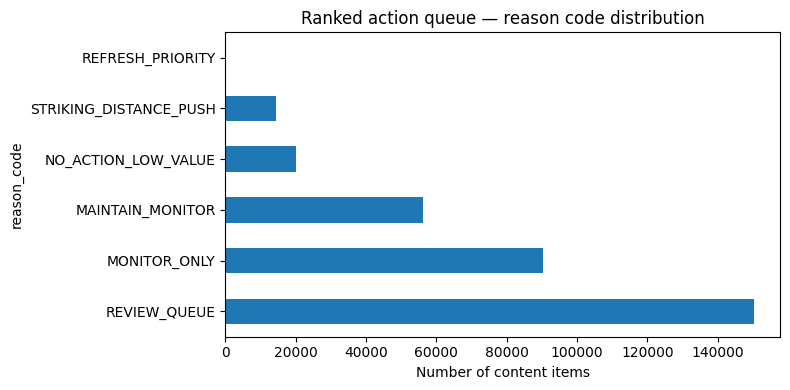

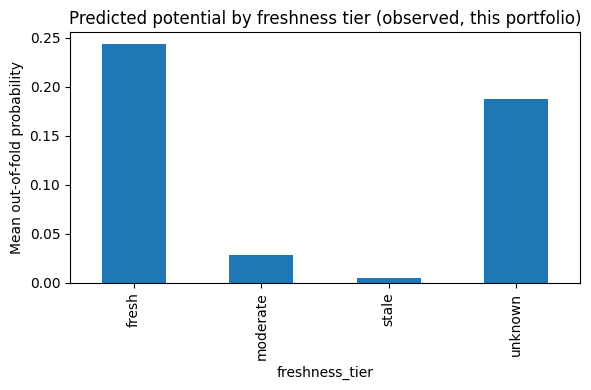

Wrote work/outputs/w07_metrics.json


In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = [
    "client_hash_id", "content_hash_id", "oof_probability", "gsc_avg_position",
    "days_since_update", "word_count", "position_tier", "freshness_tier",
    "probability_tier", "archetype", "reason_code", "reason_text", "needs_human_review"
]
ranked_queue[export_cols].to_csv("work/outputs/w07_ranked_action_queue.csv", index=False)
print("Wrote work/outputs/w07_ranked_action_queue.csv:", len(ranked_queue), "rows")

fig, ax = plt.subplots(figsize=(8, 4))
ranked_queue["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of content items")
ax.set_title("Ranked action queue — reason code distribution")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_distribution.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
freshness_summary["mean"].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean out-of-fold probability")
ax.set_title("Predicted potential by freshness tier (observed, this portfolio)")
plt.tight_layout()
plt.savefig("work/figures/w07_freshness_insight.png", dpi=150)
plt.show()

metrics_summary = {
    "model": "Logistic Regression, grouped-by-client split",
    "seed": SEED,
    "n_rows_scored": int(len(ranked_queue)),
    "grouped_test_precision": float(model_precision),
    "grouped_test_recall": float(model_recall),
    "grouped_test_f1": float(model_f1),
    "grouped_test_roc_auc": float(model_auc),
    "label_base_rate": float(y.mean()),
    "reason_code_counts": ranked_queue["reason_code"].value_counts().to_dict(),
    "share_needing_human_review": float(ranked_queue["needs_human_review"].mean()),
    "freshness_tier_mean_probability": freshness_summary["mean"].to_dict(),
    "monitoring_reference": monitoring_reference,
}

with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Wrote work/outputs/w07_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.